In [53]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.special import voigt_profile
from scipy.optimize import curve_fit

In [85]:
file = "Ocean_Opt_test.xlsx"

def voigt_model_double(x, A1, center1, gamma1, sigma1,
                       A2, delta, gamma2, sigma2, offset):

    return (
        A1 * voigt_profile(x - center1, sigma1, gamma1) +
        A2 * voigt_profile(x - (center1 + delta), sigma2, gamma2) +
        offset
    )

def voigt_model_single(x,A1, centre1, gamma1, sigma1):
    return(A1*voigt_profile(x - centre1, sigma1, gamma1))

def reduced_chi_squared(x, y, model, pop):
    theory = model(x,*pop)
    dof = len(x)-len(pop)
    chi2 = np.sum((y-theory)**2/theory)
    redchi2 = chi2/dof
    return redchi2


[2.22573206e+02 6.90777553e+02 1.82020396e-03 1.03891657e-01
 1.26108404e+05 1.74672895e+00 3.00197276e-01 9.00878688e-01
 9.21845515e+01]


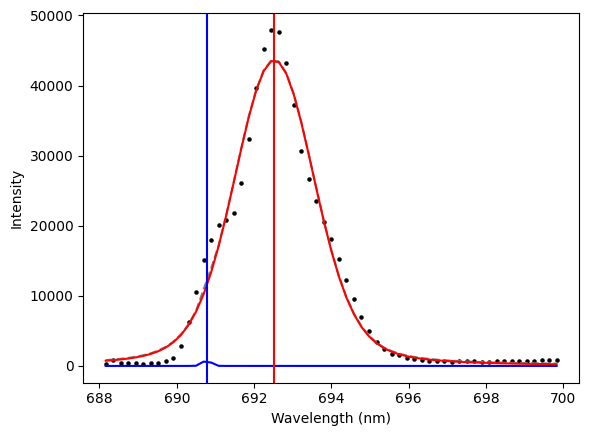

----- Results -----
R1 Theory: 693.4
R1 Obs: 692.5242820181653
R1 frac: 0.9982381739607815
R2 Theory: 692.9
R2 Obs: 690.7775530634945
R2 frac: 0.0017618260392185242
Reduced Chi Squared: 453.87134891320426


In [78]:
df = pd.read_excel(file)

wavelengths_raw = df["W_77"].to_numpy()
intensity_raw = df["I_77"].to_numpy()

wavelengths = []
intensities = []

for i in range(len(wavelengths_raw)):
    if 688 < wavelengths_raw[i]< 700:
        wavelengths.append(wavelengths_raw[i])
        intensities.append(intensity_raw[i])

p0_estimate = [np.max(intensities) / 2, 691.5, 0.3, 0.3, np.max(intensities) / 2, 1.4, 0.3, 0.3,
               np.min(intensities)]

bounds_estimate = [
    [0, 690, 0, 0, 0, 1, 0, 0, 0],  #lower
    [np.inf, 692, np.inf, np.inf, np.inf, 4, np.inf, np.inf, np.inf]  #upper
]

pop, cov = curve_fit(voigt_model_double,
                                       wavelengths,
                                       intensities,
                                       p0=p0_estimate,
                                       bounds=bounds_estimate)

rchi2 = reduced_chi_squared(wavelengths, intensities, voigt_model_double, pop)

print(pop)
values = [2.22573206e+02, 6.90777553e+02, 1.82020396e-03, 1.03891657e-01,
 1.26108404e+05, 1.74672895e+00, 3.00197276e-01, 9.00878688e-01,
 9.21845515e+01]

pop_r1 = np.array([values[0],values[1],values[2],values[3]])
pop_r2 = np.array([values[4],values[1]+values[5],values[6],values[7]])

plt.figure(1)
plt.scatter(wavelengths, intensities, s = 5, c = "black")
plt.plot(wavelengths, voigt_model_double(wavelengths, *pop), linestyle = "--", color = "grey")

plt.plot(wavelengths, voigt_model_single(wavelengths,*pop_r1), c = "b")
plt.plot(wavelengths, voigt_model_single(wavelengths,*pop_r2), c = "r")

plt.xlabel("Wavelength (nm)")
plt.ylabel("Intensity")

plt.axvline(pop[1]+pop[5], color="r")
plt.axvline(pop[1], color="b")
plt.show()
print(f"----- Results -----")
print(f"R1 Theory: 693.4")
print(f"R1 Obs: {pop[1]+pop[5]}")
print(f"R1 frac: {pop[4]/(pop[0]+pop[4])}")
print(f"R2 Theory: 692.9")
print(f"R2 Obs: {pop[1]}")
print(f"R2 frac: {pop[0]/(pop[0]+pop[4])}")
print(f"Reduced Chi Squared: {rchi2}")

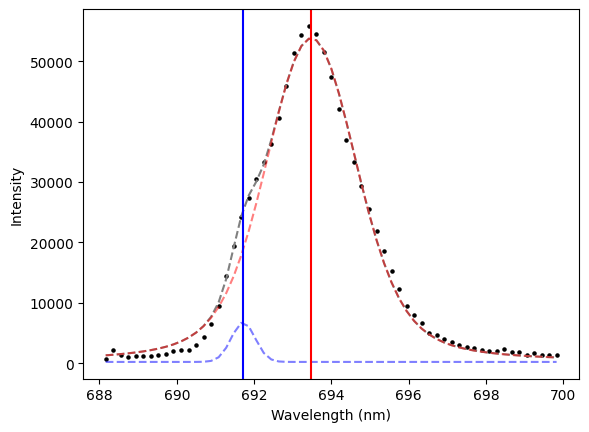

----- Results -----
R1 Theory: 693.4
R1 Obs: 693.4803623988851 plusminus 0.07497984767908417
R1 frac: 0.9731797610609816
R2 Theory: 692.9
R2 Obs: 691.7198323179258 plusminus 0.05538795289944816
R2 frac: 0.026820238939018436
Reduced Chi Squared: 206.1703885747435


In [83]:
wavelengths_raw = df["W_298"].to_numpy()
intensity_raw = df["I_298"].to_numpy()

wavelengths = []
intensities = []

for i in range(len(wavelengths_raw)):
    if 688 < wavelengths_raw[i]< 700:
        wavelengths.append(wavelengths_raw[i])
        intensities.append(intensity_raw[i])

p0_estimate = [np.max(intensities) / 2, 691.5, 0.3, 0.3, np.max(intensities) / 2, 1.4, 0.3, 0.3,
               np.min(intensities)]

bounds_estimate = [
    [0, 691, 0, 0, 0, 0.5, 0, 0, 0],  #lower
    [np.inf, 693, np.inf, np.inf, np.inf, 4, np.inf, np.inf, np.inf]  #upper
]

pop, cov = curve_fit(voigt_model_double,
                                       wavelengths,
                                       intensities,
                                       p0=p0_estimate,
                                       bounds=bounds_estimate)

rchi2 = reduced_chi_squared(wavelengths, intensities, voigt_model_double, pop)

pop_r1 = np.array([pop[0],pop[1],pop[2],pop[3]])
pop_r2 = np.array([pop[4],pop[1]+pop[5],pop[6],pop[7]])

plt.figure(1)
plt.scatter(wavelengths, intensities, s = 5, c = "black")
plt.plot(wavelengths, voigt_model_double(wavelengths, *pop), linestyle = "--", color = "grey")

plt.plot(wavelengths, voigt_model_single(wavelengths,*pop_r1)+pop[-1], c = "b",linestyle = "--", alpha = 0.5)
plt.plot(wavelengths, voigt_model_single(wavelengths,*pop_r2)+pop[-1], c = "r",linestyle = "--", alpha = 0.5)

plt.xlabel("Wavelength (nm)")
plt.ylabel("Intensity")

plt.axvline(pop[1]+pop[5], color="r")
plt.axvline(pop[1], color="b")
plt.show()
print(f"----- Results -----")
print(f"R1 Theory: 693.4")
print(f"R1 Obs: {pop[1]+pop[5]} plusminus {np.sqrt(np.diag(cov)[1]+np.diag(cov)[5])}")
print(f"R1 frac: {pop[4]/(pop[0]+pop[4])}")
print(f"R2 Theory: 692.9")
print(f"R2 Obs: {pop[1]} plusminus {np.sqrt(np.diag(cov)[1])}")
print(f"R2 frac: {pop[0]/(pop[0]+pop[4])}")
print(f"Reduced Chi Squared: {rchi2}")